Curator: Louise Marie Maganto

Reviewer: HERE (Your team member's name)

Title: A continuous-time Markov chain and stochastic differential equations approach for modeling malaria propagation

Pathogen: Malaria 

DOI: https://doi.org/10.1016/j.health.2023.100239

Figure: 9 A (Page 10)

Outcome: Successful

Notes: H means host the human and V vector is the maleria.

In [1]:
variable_names = [
    'SH',
    'IH',
    'RH',
    'SV',
    'IV'
]

"""Names of the variables in the SDE model. The order of the variables should be the same as the order of the drift and diffusion terms returned by the drift_term and diffusion_term functions."""

parameter_names = [
    'lambdaH',
    'lambdaV',
    'muH',
    'muV',
    'gammaH',
    'betaHV',
    'betaVH',
    'NH'
]
"""Names of the parameters in the SDE model. The order of the parameters should be the same as the order of the values returned by the drift_term and diffusion_term functions."""

initial_values = dict(
    SH = 99,
    IH = 1,
    RH = 0,
    SV = 999,
    IV = 1

)
"""Dictionary of initial values for the variables in the SDE model. The keys should be the variable names in variable_names and the values should be the initial values for those variables."""

parameter_values = dict(
    lambdaH = 0.000039,
    lambdaV = 0.143,
    muH = .00039,
    muV = 0.1,
    gammaH = 0.2,
    betaHV = 0.225,
    betaVH = 0.375,
    NH = 100


)
"""Dictionary of values for the parameters in the SDE model. The keys should be the parameter names in parameter_names and the values should be the values for those parameters."""

initial_time = 0.0
"""Initial time to simulate during testing and curation of the SDE model."""

final_time = 20.0
"""Final time to simulate during testing and curation of the SDE model."""


def drift_term(t, y, p):
    """The drift term(s) of the SDE model

    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The drift term(s) of the SDE model in the same order as variable_names
    """
    SH, IH, RH, SV, IV = y
    NH = SH + IH + RH #page 2
    NV = SV + IV #page 2
    lambdaH, lambdaV, muH, muV, gammaH, betaHV, betaVH, NH = p
    return [
            lambdaH - betaHV * IV * (SH/NH) - muH * SH,
            betaHV * IV * (SH/NH) - (gammaH + muH) * IH,
            gammaH * IH - muH * RH,
            lambdaV - betaVH * SV * (IH/NH) - muV * SV,
            betaVH * SV * (IH/NH) - muV * IV
        ]

    raise NotImplementedError


def diffusion_term(t, y, p):
    """The diffusion term(s) of the SDE model

    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The diffusion term(s) of the SDE model in the same order as variable_names
    """
    SH, IH, RH, SV, IV = y
    NH = SH + IH + RH
    NV = SV + IV
    lambdaH, lambdaV, muH, muV, gammaH, betaHV, betaVH, NH = p
    return[
        (muH * NH) ** 0.5 - (SH * muH) ** 0.5 - (betaHV * SH *(IV/NH))  ** 0.5,
        (betaHV * SH * (IV/NH))  ** 0.5 - (muH * IH) **0.5 - (gammaH * IH) **0.5,
        (gammaH * IH) **0.5 - (muH * RH) **0.5,
        (muV * NV) **0.5 - (betaVH * (IH/NH) * SV)  ** 0.5,
        (betaVH * (IH/NH) * SV)  ** 0.5 -  (muV * IV)
    ]

    raise NotImplementedError

# End Curation

# Begin Testing

*Do not modify anything below this cell.*

Successful implementations can execute the cells below in order without error to produce a figure.

## Do checks

In [2]:
missing_ics = [n for n in variable_names if n not in initial_values]
missing_params = [n for n in parameter_names if n not in parameter_values]

found_errors = False
if len(missing_ics) > 0:
    print(f"Error: Missing initial values for variables: {missing_ics}")
    found_errors = True
if len(missing_params) > 0:
    print(f"Error: Missing values for parameters: {missing_params}")
    found_errors = True
test_drift = drift_term(initial_time, [initial_values[n] for n in variable_names], [parameter_values[n] for n in parameter_names])
test_diffusion = diffusion_term(initial_time, [initial_values[n] for n in variable_names], [parameter_values[n] for n in parameter_names])
if len(test_drift) != len(variable_names):
    print(f"Error: The drift term function should return a list of the same length as variable_names. Expected length {len(variable_names)}, but got {len(test_drift)}.")
    found_errors = True
if len(test_diffusion) != len(variable_names):
    print(f"Error: The diffusion term function should return a list of the same length as variable_names. Expected length {len(variable_names)}, but got {len(test_diffusion)}.")
    found_errors = True
if found_errors:
    raise ValueError("Failed to define the SDE model.")

## Do simulation test

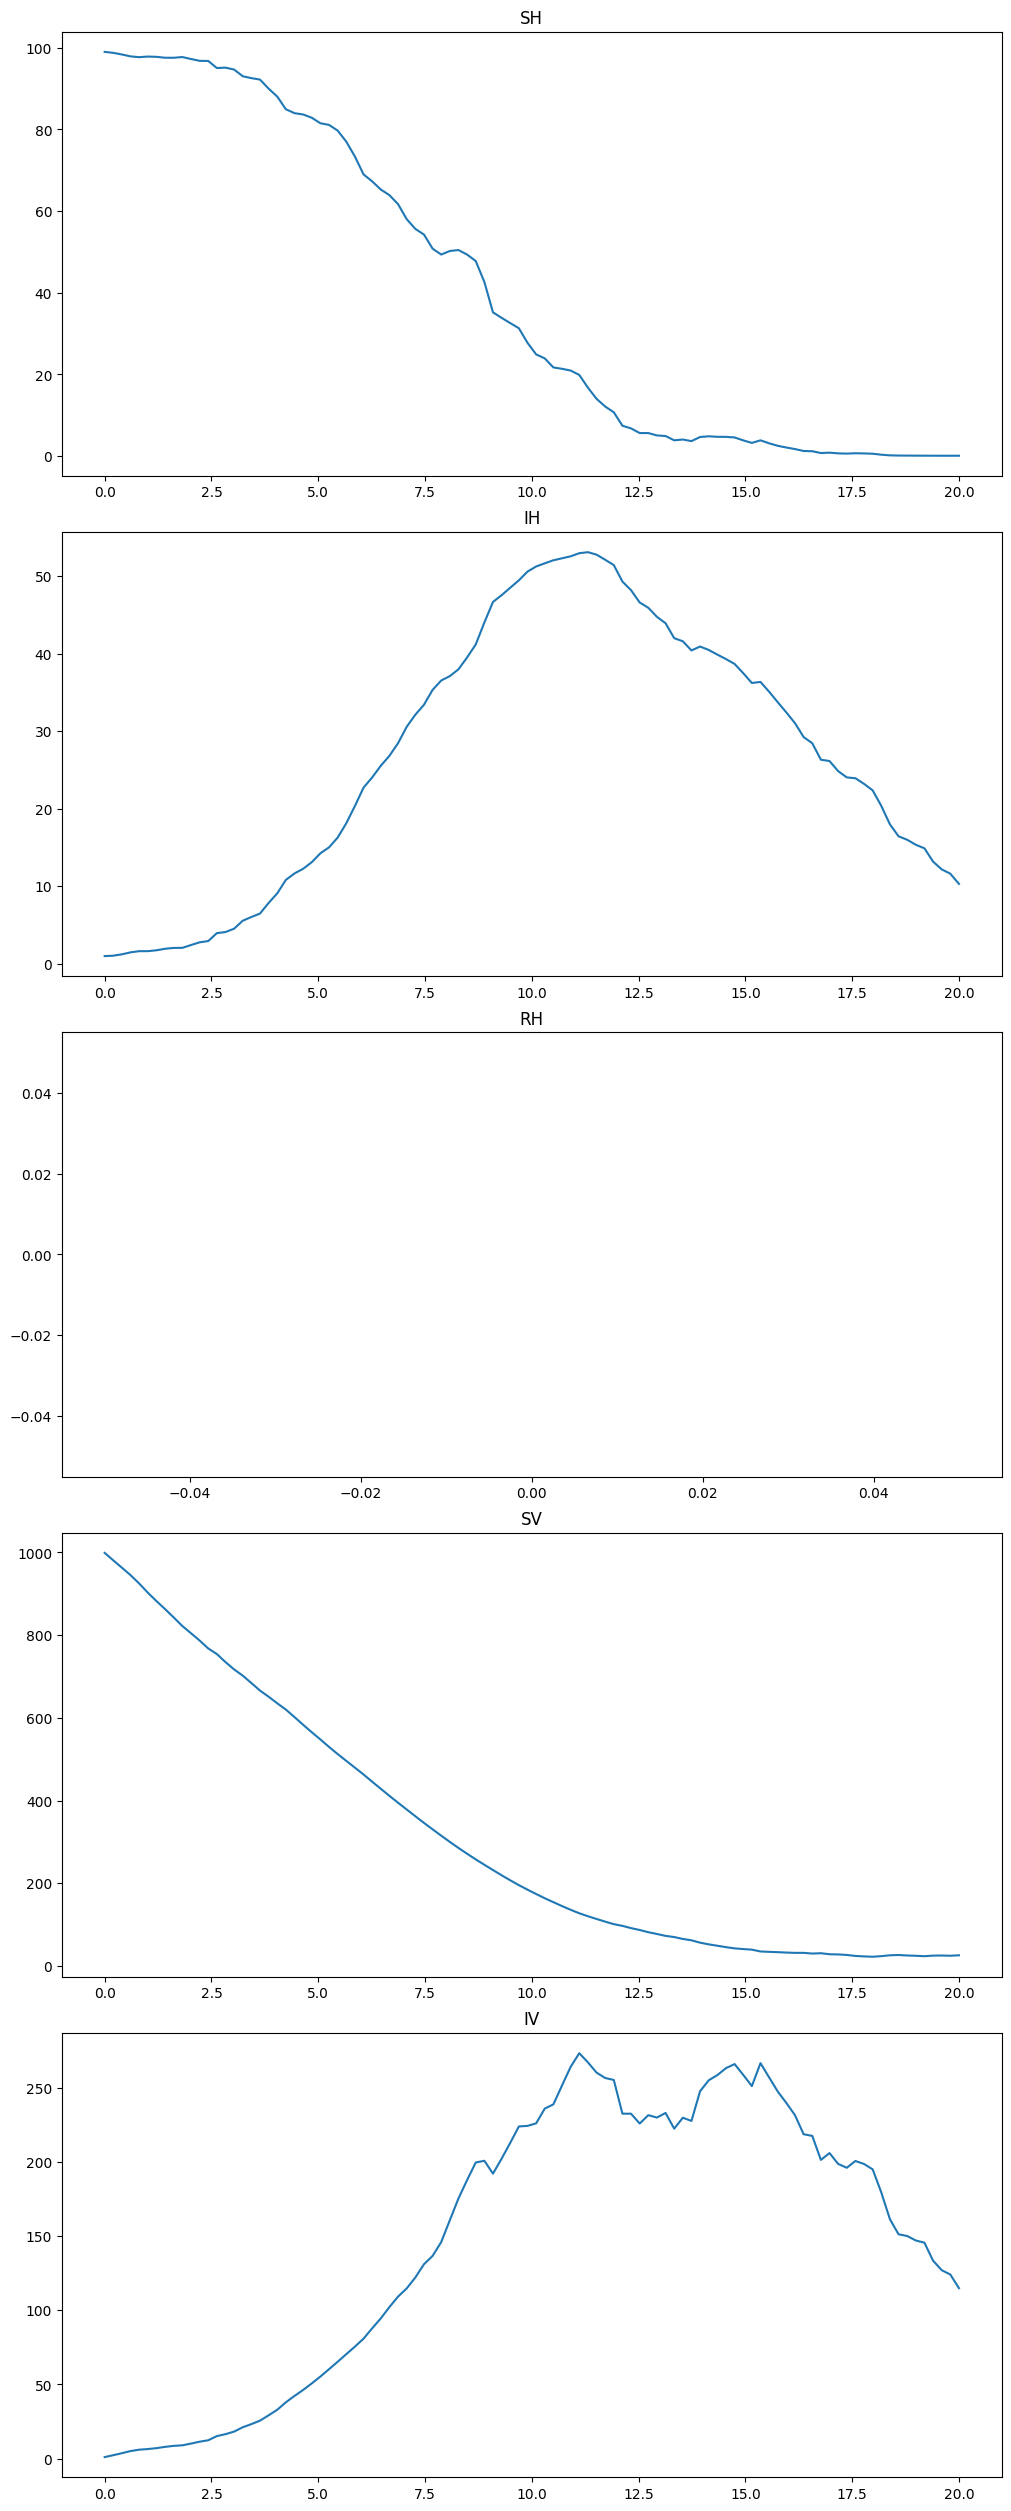

In [3]:
import diffrax
import jax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import numpy as np

sim_times = np.linspace(initial_time, final_time, 100)
dt = (final_time - initial_time) / 1000
dr_term = diffrax.ODETerm(lambda t, y, p: jnp.array(drift_term(t, y, p)))
br_term = diffrax.VirtualBrownianTree(t0=initial_time, t1=final_time, tol=dt / 10, shape=(), key=jax.random.PRNGKey(0))
di_term = diffrax.ControlTerm(lambda t, y, p: jnp.array(diffusion_term(t, y, p)), br_term)
sde_terms = diffrax.MultiTerm(dr_term, di_term)
solver = diffrax.Euler()
solution = diffrax.diffeqsolve(
    sde_terms,
    solver,
    t0=initial_time,
    t1=final_time,
    dt0=dt,
    y0=jnp.asarray([initial_values[n] for n in variable_names]),
    args=jnp.asarray([parameter_values[n] for n in parameter_names]),
    saveat=diffrax.SaveAt(ts=jnp.asarray(sim_times)),
    max_steps=None,
    throw=True
).ys

fig, axs = plt.subplots(len(variable_names), 1, figsize=(10, 5 * len(variable_names)), layout="constrained")
for i, name in enumerate(variable_names):
    axs[i].plot(sim_times, solution[:, i])
    axs[i].set_title(name)

In [4]:
print('Sucessfully defined the SDE model and generated a test simulation plot.')

Sucessfully defined the SDE model and generated a test simulation plot.
